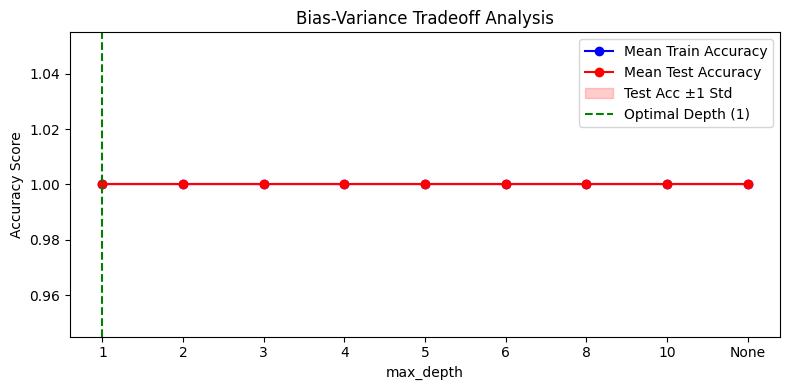

max_depth, Mean Train Acc, Mean Test Acc, Std Test Acc, Gap
1         |          1.000 |         1.000 |        0.000 | 0.000
2         |          1.000 |         1.000 |        0.000 | 0.000
3         |          1.000 |         1.000 |        0.000 | 0.000
4         |          1.000 |         1.000 |        0.000 | 0.000
5         |          1.000 |         1.000 |        0.000 | 0.000
6         |          1.000 |         1.000 |        0.000 | 0.000
8         |          1.000 |         1.000 |        0.000 | 0.000
10        |          1.000 |         1.000 |        0.000 | 0.000
None      |          1.000 |         1.000 |        0.000 | 0.000


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

df = pd.read_csv("students_feature_engineered_v2.csv")
X = df.drop(columns=["Pass"])
y = df["Pass"]

depths = [1, 2, 3, 4, 5, 6, 8, 10, None]
labels = [str(d) for d in depths]
tr_means = []
te_means = []
te_stds = []

for d in depths:
    pipe = Pipeline([
        ('sc', StandardScaler()),
        ('clf', DecisionTreeClassifier(max_depth=d, random_state=42))
    ])
    cv = cross_validate(pipe, X, y, cv=5, scoring='accuracy', return_train_score=True)
    tr_means.append(cv['train_score'].mean())
    te_means.append(cv['test_score'].mean())
    te_stds.append(cv['test_score'].std())

tr_means = np.array(tr_means)
te_means = np.array(te_means)
te_stds = np.array(te_stds)

plt.figure(figsize=(8, 4))
plt.plot(labels, tr_means, marker='o', label='Mean Train Accuracy', color='blue')
plt.plot(labels, te_means, marker='o', label='Mean Test Accuracy', color='red')
plt.fill_between(labels, te_means - te_stds, te_means + te_stds, alpha=0.2, color='red', label='Test Acc ±1 Std')

best_idx = np.argmax(te_means)
plt.axvline(x=labels[best_idx], color='green', linestyle='--', label=f'Optimal Depth ({labels[best_idx]})')
plt.xlabel('max_depth')
plt.ylabel('Accuracy Score')
plt.title('Bias-Variance Tradeoff Analysis')
plt.legend()
plt.tight_layout()
plt.savefig('bias_variance_curve.png')
plt.show()

print("max_depth, Mean Train Acc, Mean Test Acc, Std Test Acc, Gap")
for i, d in enumerate(labels):
    gap = tr_means[i] - te_means[i]
    print(f"{d:9s} | {tr_means[i]:14.3f} | {te_means[i]:13.3f} | {te_stds[i]:12.3f} | {gap:.3f}")

In [7]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

df = pd.read_csv("students_feature_engineered_v2.csv")
X = df.drop(columns=["Pass"])
y = df["Pass"]
cuter_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=0)

param_grid = {
    'clf__max_depth': [2, 3, 4, 5],
    'clf__min_samples_split': [2, 5, 10]
}

outer_scores = []
for fold, (tr_idx, te_idx) in enumerate(outer_cv.split(X, y), 1):
    X_tr, X_te = X.values[tr_idx], X.values[te_idx]
    y_tr, y_te = y.values[tr_idx], y.values[te_idx]
    
    pipe = Pipeline([
        ('sc', StandardScaler()),
        ('clf', DecisionTreeClassifier(random_state=42))
    ])
    grid_search = GridSearchCV(pipe, param_grid, cv=inner_cv, scoring='accuracy', n_jobs=-1)
    grid_search.fit(X_tr, y_tr)
    
    best_model = grid_search.best_estimator_
    score = accuracy_score(y_te, best_model.predict(X_te))
    
    outer_scores.append(score)
    print(f"Outer Fold {fold} Score: {score:.3f} | Selected Params: {grid_search.best_params_}")

print(f'\nNested CV mean: {np.mean(outer_scores):.3f} ± {np.std(outer_scores):.3f}')

Outer Fold 1 Score: 1.000 | Selected Params: {'clf__max_depth': 2, 'clf__min_samples_split': 2}
Outer Fold 2 Score: 1.000 | Selected Params: {'clf__max_depth': 2, 'clf__min_samples_split': 2}
Outer Fold 3 Score: 1.000 | Selected Params: {'clf__max_depth': 2, 'clf__min_samples_split': 2}
Outer Fold 4 Score: 1.000 | Selected Params: {'clf__max_depth': 2, 'clf__min_samples_split': 2}
Outer Fold 5 Score: 1.000 | Selected Params: {'clf__max_depth': 2, 'clf__min_samples_split': 2}

Nested CV mean: 1.000 ± 0.000


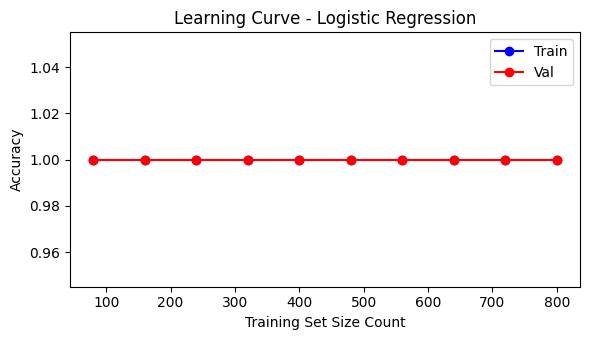

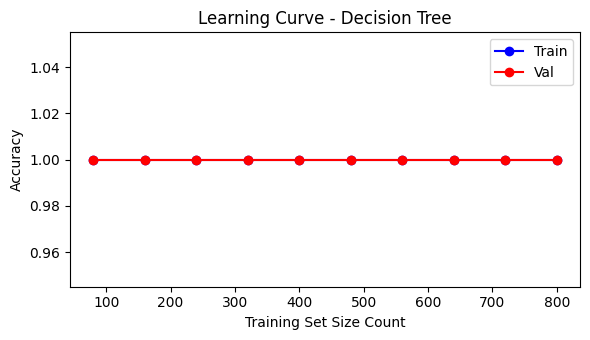

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

df = pd.read_csv("students_feature_engineered_v2.csv")
X = df.drop(columns=["Pass"])
y = df["Pass"]
pipe_lr = Pipeline([('sc', StandardScaler()), ('clf', LogisticRegression(max_iter=500))])
sizes_lr, tr_scores_lr, val_scores_lr = learning_curve(
    pipe_lr, X, y, cv=5, scoring='accuracy', train_sizes=np.linspace(0.1, 1.0, 10)
)

plt.figure(figsize=(6, 3.5))
plt.plot(sizes_lr, tr_scores_lr.mean(axis=1), 'o-', color='blue', label='Train')
plt.plot(sizes_lr, val_scores_lr.mean(axis=1), 'o-', color='red', label='Val')
plt.xlabel('Training Set Size Count')
plt.ylabel('Accuracy')
plt.title('Learning Curve - Logistic Regression')
plt.legend()
plt.tight_layout()
plt.savefig('learning_curve_lr.png')
plt.show()
pipe_dt = Pipeline([('sc', StandardScaler()), ('clf', DecisionTreeClassifier(max_depth=None, random_state=42))])
sizes_dt, tr_scores_dt, val_scores_dt = learning_curve(
    pipe_dt, X, y, cv=5, scoring='accuracy', train_sizes=np.linspace(0.1, 1.0, 10)
)
plt.figure(figsize=(6, 3.5))
plt.plot(sizes_dt, tr_scores_dt.mean(axis=1), 'o-', color='blue', label='Train')
plt.plot(sizes_dt, val_scores_dt.mean(axis=1), 'o-', color='red', label='Val')
plt.xlabel('Training Set Size Count')
plt.ylabel('Accuracy')
plt.title('Learning Curve - Decision Tree')
plt.legend()
plt.tight_layout()
plt.savefig('learning_curve_dt.png')
plt.show()

LogisticRegression, Accuracy: 1.000, AUC: 1.000, Optimal Threshold: 0.991
DecisionTree_d3   , Accuracy: 1.000, AUC: 1.000, Optimal Threshold: 1.000
RandomForest      , Accuracy: 1.000, AUC: 1.000, Optimal Threshold: 1.000


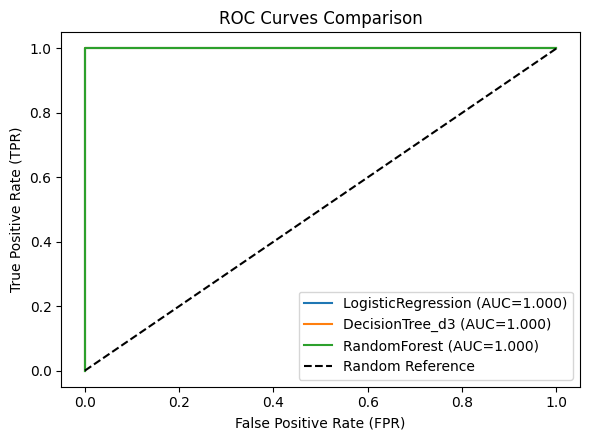

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score

df = pd.read_csv("students_feature_engineered_v2.csv")
X = df.drop(columns=["Pass"])
y = df["Pass"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

classifiers = {
    'LogisticRegression': LogisticRegression(max_iter=500),
    'DecisionTree_d3': DecisionTreeClassifier(max_depth=3, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
}

fig, ax = plt.subplots(figsize=(6, 4.5))

for name, clf in classifiers.items():
    pipe = Pipeline([('sc', StandardScaler()), ('clf', clf)])
    pipe.fit(X_train, y_train)
    
    proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    acc = accuracy_score(y_test, pipe.predict(X_test))
    
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
    j_scores = tpr - fpr
    opt_idx = np.argmax(j_scores)
    print(f"{name:18s}, Accuracy: {acc:.3f}, AUC: {auc:.3f}, Optimal Threshold: {thresholds[opt_idx]:.3f}")

ax.plot([0, 1], [0, 1], 'k--', label='Random Reference')
ax.set_xlabel('False Positive Rate (FPR)')
ax.set_ylabel('True Positive Rate (TPR)')
ax.set_title('ROC Curves Comparison')
ax.legend()
plt.tight_layout()
plt.savefig('roc_curves.png')
plt.show()

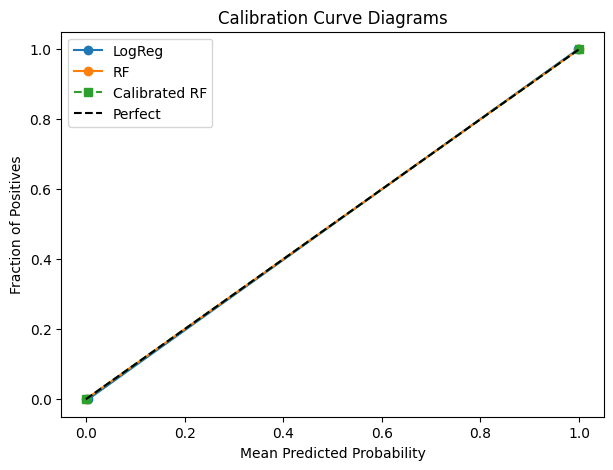


Threshold, Precision, Recall, F1
      0.1,     1.000,  1.000, 1.000
      0.2,     1.000,  1.000, 1.000
      0.3,     1.000,  1.000, 1.000
      0.4,     1.000,  1.000, 1.000
      0.5,     1.000,  1.000, 1.000
      0.6,     1.000,  1.000, 1.000
      0.7,     1.000,  1.000, 1.000
      0.8,     1.000,  1.000, 1.000
      0.9,     1.000,  1.000, 1.000


In [ ]:
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
import matplotlib.pyplot as plt

pipe_rf = Pipeline([
    ('sc', StandardScaler()),
    ('clf', RandomForestClassifier(random_state=42))
])

pipe_lr.fit(X_train, y_train)
pipe_rf.fit(X_train, y_train)

proba_lr = pipe_lr.predict_proba(X_test)[:, 1]
proba_rf = pipe_rf.predict_proba(X_test)[:, 1]

plt.figure(figsize=(7, 5))
for name, proba in [('LogReg', proba_lr), ('RF', proba_rf)]:
    frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=10)
    plt.plot(mean_pred, frac_pos, marker='o', label=name)

cal_rf = CalibratedClassifierCV(estimator=pipe_rf, cv=5, method='isotonic')
cal_rf.fit(X_train, y_train)
proba_rf_cal = cal_rf.predict_proba(X_test)[:, 1]

frac_pos_cal, mean_pred_cal = calibration_curve(y_test, proba_rf_cal, n_bins=10)
plt.plot(mean_pred_cal, frac_pos_cal, marker='s', linestyle='--', label='Calibrated RF')

plt.plot([0,1],[0,1],'k--', label='Perfect')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.legend()
plt.title('Calibration Curve Diagrams')
plt.show()
thresholds = np.linspace(0.1, 0.9, 9)
print("\nThreshold, Precision, Recall, F1")
for t in thresholds:
    preds = (proba_rf >= t).astype(int)
    p = precision_score(y_test, preds, zero_division=0)
    r = recall_score(y_test, preds)
    f = f1_score(y_test, preds)
    print(f"{t:9.1f}, {p:9.3f}, {r:6.3f}, {f:5.3f}")

                   mean  std
Height_cm           0.0  0.0
Weight_kg           0.0  0.0
BMI                 0.0  0.0
Days_Since_Enroll   0.0  0.0
City_Mumbai         0.0  0.0
City_Pune           0.0  0.0


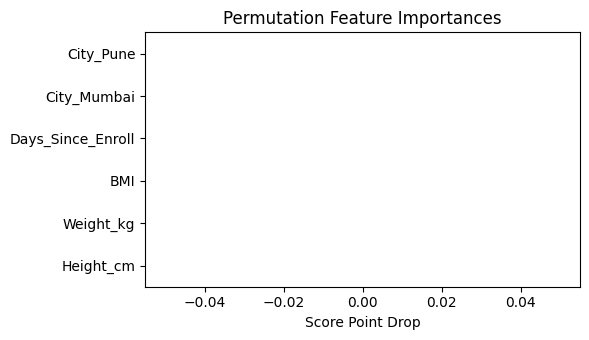


Baseline Accuracy: 1.000
Top-5 Features Accuracy: 1.000


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score

df = pd.read_csv("students_feature_engineered_v2.csv")
X = df.drop(columns=["Pass"])
y = df["Pass"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

rf_pipe = Pipeline([('sc', StandardScaler()), ('clf', RandomForestClassifier(n_estimators=100, random_state=42))])
rf_pipe.fit(X_train, y_train)

result = permutation_importance(rf_pipe, X_test, y_test, n_repeats=30, random_state=42)
perm_df = pd.DataFrame(result.importances.T, columns=X.columns)
summary = perm_df.agg(['mean', 'std']).T.sort_values('mean', ascending=False)
print(summary.round(4))
plt.figure(figsize=(6, 3.5))
summary['mean'].sort_values().plot(kind='barh', color='teal', xerr=summary['std'])
plt.title('Permutation Feature Importances')
plt.xlabel('Score Point Drop')
plt.tight_layout()
plt.show()
top_5 = summary.index[:5].tolist()
X_tr_5, X_te_5 = X_train[top_5], X_test[top_5]

pipe_5 = Pipeline([('sc', StandardScaler()), ('clf', RandomForestClassifier(n_estimators=100, random_state=42))]).fit(X_tr_5, y_train)
print(f"\nBaseline Accuracy: {accuracy_score(y_test, rf_pipe.predict(X_test)):.3f}")
print(f"Top-5 Features Accuracy: {accuracy_score(y_test, pipe_5.predict(X_te_5)):.3f}")

SKFold-5        | Mean: 1.000 | Std: 0.000 | Total Scores Collected: 5
RepSKFold-5x10  | Mean: 1.000 | Std: 0.000 | Total Scores Collected: 50
RepSKFold-5x30  | Mean: 1.000 | Std: 0.000 | Total Scores Collected: 150


C:\Users\USER\AppData\Local\Temp\ipykernel_7932\279325815.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(list(results.values()), labels=list(results.keys()))


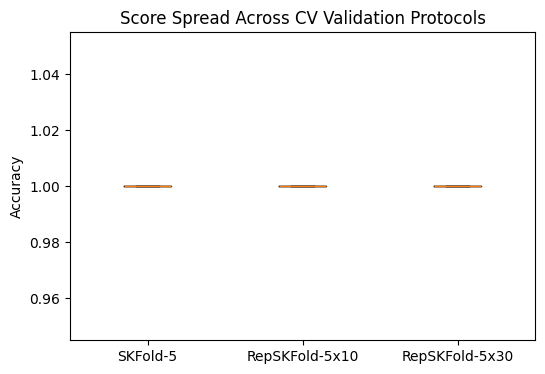


T-Test Check -> T-Stat: nan | P-Value: nan


C:\Users\USER\AppData\Roaming\Python\Python314\site-packages\scipy\stats\_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from scipy.stats import ttest_ind

df = pd.read_csv("students_feature_engineered_v2.csv")
X = df.drop(columns=["Pass"])
y = df["Pass"]

pipe = Pipeline([('sc', StandardScaler()), ('clf', DecisionTreeClassifier(max_depth=3, random_state=42))])

protocols = {
    'SKFold-5': StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    'RepSKFold-5x10': RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42),
    'RepSKFold-5x30': RepeatedStratifiedKFold(n_splits=5, n_repeats=30, random_state=42),
}

results = {}
for name, cv_obj in protocols.items():
    scores = cross_val_score(pipe, X, y, cv=cv_obj, scoring='accuracy')
    results[name] = scores
    print(f"{name:15s} | Mean: {scores.mean():.3f} | Std: {scores.std():.3f} | Total Scores Collected: {len(scores)}")
plt.figure(figsize=(6, 4))
plt.boxplot(list(results.values()), labels=list(results.keys()))
plt.title('Score Spread Across CV Validation Protocols')
plt.ylabel('Accuracy')
plt.savefig('repeated_cv_boxplot.png')
plt.show()

t_stat, p_val = ttest_ind(results['SKFold-5'], results['RepSKFold-5x30'])
print(f"\nT-Test Check -> T-Stat: {t_stat:.4f} | P-Value: {p_val:.4f}")

In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import make_scorer, confusion_matrix

df = pd.read_csv("students_feature_engineered_v2.csv")
X = df.drop(columns=["Pass"])
y = df["Pass"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
FN_COST = 5
FP_COST = 1
def cost_calculation_logic(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    cost = (FN_COST * fn) + (FP_COST * fp)
    return -cost  

cost_scorer = make_scorer(cost_calculation_logic)

param_grid = {'clf__max_depth': [2, 3, 4, 5], 'clf__min_samples_split': [2, 5, 10]}
pipe = Pipeline([('sc', StandardScaler()), ('clf', DecisionTreeClassifier(random_state=42))])

grid_cost = GridSearchCV(pipe, param_grid, cv=5, scoring=cost_scorer, n_jobs=-1).fit(X_train, y_train)
print("Best Cost Optimized Hyperparameters:", grid_cost.best_params_)

grid_acc = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy', n_jobs=-1).fit(X_train, y_train)
print("Best Accuracy Optimized Hyperparameters:", grid_acc.best_params_)

proba_test = grid_cost.best_estimator_.predict_proba(X_test)[:, 1]
thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

print("\nThreshold | FP Count | FN Count | Total Cost Penalty")
for t in thresholds:
    preds = (proba_test >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    total_cost = (FN_COST * fn) + (FP_COST * fp)
    print(f"{t:9.1f} | {fp:8d} | {fn:8d} | {total_cost:18d}")

Best Cost Optimized Hyperparameters: {'clf__max_depth': 2, 'clf__min_samples_split': 2}
Best Accuracy Optimized Hyperparameters: {'clf__max_depth': 2, 'clf__min_samples_split': 2}

Threshold | FP Count | FN Count | Total Cost Penalty
      0.2 |        0 |        0 |                  0
      0.3 |        0 |        0 |                  0
      0.4 |        0 |        0 |                  0
      0.5 |        0 |        0 |                  0
      0.6 |        0 |        0 |                  0
      0.7 |        0 |        0 |                  0
      0.8 |        0 |        0 |                  0


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, GridSearchCV, RandomizedSearchCV, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, classification_report, confusion_matrix
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance
from scipy.stats import randint

cancer = load_breast_cancer()
X_bc = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y_bc = pd.Series(cancer.target)

X_tr, X_te, y_tr, y_te = train_test_split(X_bc, y_bc, test_size=0.20, random_state=42, stratify=y_bc)

lr_pipe = Pipeline([('sc', StandardScaler()), ('clf', LogisticRegression(max_iter=2000))])
base_score = cross_val_score(lr_pipe, X_tr, y_tr, cv=5, scoring='accuracy')
print(f"Step 2 Baseline CV Accuracy: {base_score.mean():.3f} ± {base_score.std():.3f}")

dt_raw = Pipeline([('sc', StandardScaler()), ('clf', DecisionTreeClassifier(max_depth=None, random_state=42))])
cv_dt = cross_validate(dt_raw, X_tr, y_tr, cv=5, scoring='accuracy', return_train_score=True)
print(f"Step 3 Raw DT Folds -> Train Acc: {cv_dt['train_score'].mean():.3f} | Test Acc: {cv_dt['test_score'].mean():.3f}")

sizes, tr_s, va_s = learning_curve(lr_pipe, X_tr, y_tr, cv=5, scoring='accuracy')
plt.figure(figsize=(5, 3.5))
plt.plot(sizes, tr_s.mean(axis=1), label='Train')
plt.plot(sizes, va_s.mean(axis=1), label='Val')
plt.title('BC Learning Curve')
plt.legend()
plt.savefig('bc_learning_curve.png')
plt.close()

grid_p = {'clf__max_depth': [2,3,4,5,6], 'clf__min_samples_split': [2,5,10], 'clf__criterion': ['gini','entropy']}
dt_tune = Pipeline([('sc', StandardScaler()), ('clf', DecisionTreeClassifier(random_state=42))])
grid_search = GridSearchCV(dt_tune, grid_p, cv=5, scoring='roc_auc', n_jobs=-1).fit(X_tr, y_tr)
print(f"Step 5 Best Tree CV AUC Score: {grid_search.best_score_:.3f}")

rand_p = {'clf__n_estimators': randint(50, 200), 'clf__max_depth': [3,4,5,None]}
rf_tune = Pipeline([('sc', StandardScaler()), ('clf', RandomForestClassifier(random_state=42))])
rand_search = RandomizedSearchCV(rf_tune, rand_p, n_iter=40, cv=5, scoring='roc_auc', n_jobs=-1, random_state=42).fit(X_tr, y_tr)
print(f"Step 6 Best Forest CV AUC Score: {rand_search.best_score_:.3f}")

winner = rand_search.best_estimator_ if rand_search.best_score_ > grid_search.best_score_ else grid_search.best_estimator_
preds = winner.predict(X_te)
probas = winner.predict_proba(X_te)[:, 1]

print(f"\n[WINNING MODEL TEST EVALUATION RESULTS]")
print(f"Final Step 7 Accuracy Score: {accuracy_score(y_te, preds):.3f}")
print(f"Final Test Area Under ROC Curve (AUC): {roc_auc_score(y_te, probas):.3f}")
print("\nClassification Summary Breakdown:\n", classification_report(y_te, preds))
print("Confusion Matrix Layout:\n", confusion_matrix(y_te, preds))

fpr, tpr, _ = roc_curve(y_te, probas)
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label=f'ROC Trace (AUC={roc_auc_score(y_te, probas):.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('Final Winning ROC Curve')
plt.legend()
plt.savefig('bc_roc_curve.png')
plt.close()

frac_pos, mean_p = calibration_curve(y_te, probas, n_bins=5)
plt.figure(figsize=(5, 4))
plt.plot(mean_p, frac_pos, marker='o', label='Winner Calibration Trace')
plt.plot([0, 1], [0, 1], 'k--')
plt.savefig('bc_calibration.png')
plt.close()

pi = permutation_importance(winner, X_te, y_te, n_repeats=10, random_state=42)
top_10_indices = np.argsort(pi.importances_mean)[::-1][:10]
print("\nTop 10 Most Important Features:")
for index in top_10_indices:
    print(f"{cancer.feature_names[index]:30s} : {pi.importances_mean[index]:.4f}")

Step 2 Baseline CV Accuracy: 0.980 ± 0.013
Step 3 Raw DT Folds -> Train Acc: 1.000 | Test Acc: 0.910
Step 5 Best Tree CV AUC Score: 0.951
Step 6 Best Forest CV AUC Score: 0.990

[WINNING MODEL TEST EVALUATION RESULTS]
Final Step 7 Accuracy Score: 0.956
Final Test Area Under ROC Curve (AUC): 0.993

Classification Summary Breakdown:
               precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

Confusion Matrix Layout:
 [[39  3]
 [ 2 70]]

Top 10 Most Important Features:
worst area                     : 0.0070
mean concave points            : 0.0070
worst texture                  : 0.0061
worst concave points           : 0.0061
worst concavity                : 0.0035
area error                     : 0.0026
worst perimeter      